# Day 22 Prediksi Tip Restoran

Di notebook ini kita memprediksi **besarnya tip** yang diberikan tamu restoran
berdasarkan total tagihan, jumlah orang, hari, dan faktor lain. Fokus utamanya
adalah **feature engineering** (membuat fitur baru) dan **encoding** data kategori
agar bisa dipakai model regresi.

> 🎯 **Tujuan Pembelajaran**
> - Membuat fitur baru `tip_pct` (persentase tip terhadap tagihan).
> - Meng-*encode* kolom kategori (`sex`, `smoker`, `day`, `time`) jadi angka.
> - Melatih **Linear Regression** dan menafsirkan **koefisien**.
> - Mengevaluasi model dengan **R², MAE, RMSE**.

##Tentang Dataset

Kita memakai **Tips Dataset** klasik dari seaborn — catatan tip di sebuah restoran.

- **Sumber:** [Kaggle — ranjeetjain3/seaborn-tips-dataset](https://www.kaggle.com/datasets/ranjeetjain3/seaborn-tips-dataset)
- **Jumlah data:** 244 baris × 7 kolom

| Kolom | Arti |
|-------|------|
| `total_bill` | Total tagihan (USD) |
| `tip` | Besar tip yang diberikan (USD) — **target** |
| `sex` | Jenis kelamin pembayar |
| `smoker` | Apakah di area perokok (Yes/No) |
| `day` | Hari (Thur/Fri/Sat/Sun) |
| `time` | Waktu makan (Lunch/Dinner) |
| `size` | Jumlah orang di meja |

## Import Library

- **pandas/numpy** → olah data & angka.
- **matplotlib/seaborn** → visualisasi.
- **scikit-learn** → `train_test_split`, `LinearRegression`, metrik regresi.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Import Dataset

In [18]:
!pip install kaggle

!kaggle datasets download -d ranjeetjain3/seaborn-tips-dataset


Dataset URL: https://www.kaggle.com/datasets/ranjeetjain3/seaborn-tips-dataset
License(s): unknown
seaborn-tips-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [19]:
!unzip seaborn-tips-dataset.zip

Archive:  seaborn-tips-dataset.zip
replace tips.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: tips.csv                


## Eksplorasi awal Dataset

In [20]:
df = pd.read_csv('tips.csv')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


In [23]:
df.isna().sum().sum()

np.int64(0)

Interpretasi:

-  Tiap baris adalah satu transaksi. `tip` adalah yang ingin kita prediksi.
- 244 baris, tanpa nilai kosong. Empat kolom bertipe `object`
(kategori) dan harus di-*encode* sebelum masuk model.
- Rata-rata tagihan ~19.8 USD dan tip ~3 USD. Ukuran meja
umumnya 2–3 orang. Rentang tip cukup lebar (1–10 USD).
- Tidak ada nilai hilang — langsung lanjut ke feature engineering.

## Feature Engineering

- Buat Fitut `tip_pctg` = persentase tip terhadap tagihan.

ini akan membantu memahami perilaku tamu ( apakah persentase tip stabil ), sekaligus menjadi fitur turunan yang berguna untuk dianalisis

In [24]:
df ['tip_pctg'] = df['tip'] / df ['total_bill'] * 100

print("rata rata persentase tip: %.1f%%" % df['tip_pctg'].mean())
df[["total_bill", "tip", "tip_pctg"]].head()

rata rata persentase tip: 16.1%


,total_bill,tip,tip_pctg
0,16.99,1.01,5.944673
1,10.34,1.66,16.054159
2,21.01,3.50,16.658734
3,23.68,3.31,13.978041
4,24.59,3.61,14.680765


Interpretasi:
- Rata-rata tamu memberi tip sekitar 16% dari tagihan
- angka yang wajar untuk budaya restoran di Amerika Serikat
- Persentase ini relatif stabil , menandakan `Total_bill` adalah penentu utama besar tips

## EDA dan Visualisasi

### a) Hubungan total_bill dengan Tip

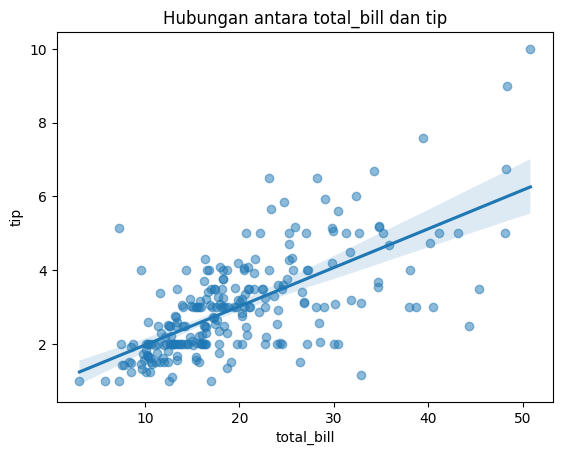

In [25]:
sns.regplot(data=df, x='total_bill', y='tip', scatter_kws={"alpha":0.5})


plt.title('Hubungan antara total_bill dan tip')
plt.xlabel('total_bill')
plt.ylabel('tip')
plt.show()

Interpretasi:
- Hubungan Positif antara `total_bill` dengan `tip`
- makin besar tagihan semakin besar jumlah tip
- garis trend naik menandakan `total_bill` adalah prediktor paling kuat

### b) Distribusi persentase Tip

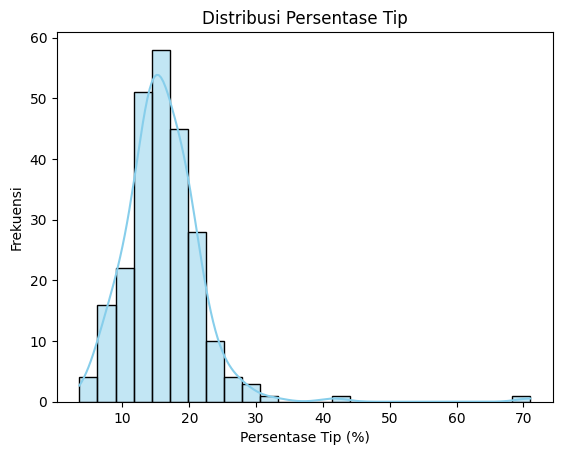

In [26]:
sns.histplot(df['tip_pctg'], bins=25, kde=True, color='skyblue')
plt.title('Distribusi Persentase Tip')
plt.xlabel('Persentase Tip (%)')
plt.ylabel('Frekuensi')
plt.show()

Interpretasi:
- Sebagian besar pelanggan memberi tip 10-20%
- ada beberapa pelanggan memberi tip diatas 40% dari total bill dan ini merupakan outlier
- mayoritas terkonsentrasi di sekitar 14-20%

### c) Rata-rata tip perhari dan Waktu ( Bar )

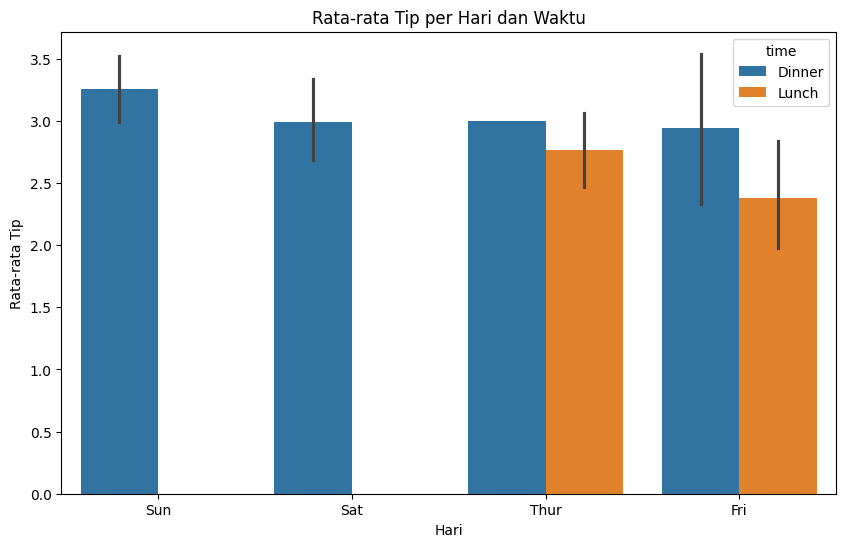

In [27]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='day', y='tip', hue='time')
plt.title('Rata-rata Tip per Hari dan Waktu')
plt.xlabel('Hari')
plt.ylabel('Rata-rata Tip')
plt.show()

Interpretasi:
- Tip cenderung lebih besar saat makan malam dibanding makan siang
- Tip pada akhir pekan sedikit lebih tinggi, bisa diakibatkan tagihan makan malam akhir pekan lebih besar

## Preprocessing - Encoding & Train/Test Split

Model Machine Learning belajar hanya dari angka.

  - maka kita akan mengubah kolom object / kategorik menjadi kolom numerikal, dan untuk kasus saat ini gunakan teknik `one hot encoding` menggunakan (`pd.get_dummies`).

  - hapus kolom `tip_pctg` sebagai fitur data latih, karna akan membocorkan jawaban atau target

In [28]:
feat_cat = ['sex', 'smoker', 'day', 'time']

X = pd.get_dummies(df.drop(columns=['tip', 'tip_pctg']), columns=feat_cat, drop_first=True)
y = df['tip']

print(X.shape)
X.head()

(244, 8)


,total_bill,size,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,16.99,2,False,False,False,True,False,False
1,10.34,3,True,False,False,True,False,False
2,21.01,3,True,False,False,True,False,False
3,23.68,2,True,False,False,True,False,False
4,24.59,4,False,False,False,True,False,False


In [29]:
#Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(195, 8)
(49, 8)


Interpretasi:
- `drop_first=True` membuang 1 kategori sebagai acuan agar tidak redudan
-  data dibagi 80% untuk data latih dan 20% untuk data test

## Modeling - Linear Regression

In [30]:
model = LinearRegression()

In [31]:
model.fit(X_train, y_train)

LinearRegression()

In [32]:
y_pred = model.predict(X_test)

## Evaluasi Model


In [36]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print (f'R2: {r2:.2f}')
print (f'MAE: {mae:.2f}  USD')
print (f'RMSE: {np.sqrt(mse):.2f} USD')

R2: 0.44
MAE: 0.67  USD
RMSE: 0.84 USD


Interpretasi:
  - `R2` Model berhasil menjelaskan 44% variasi dari besarnya tip yang diberikan tamu restoran.

  - `MAE` Secara rata-rata, selisih antara prediksi model dan nilai tip yang sebenarnya adalah $0.67 (sekitar 67 sen dolar)

  - `RMSE` Mirip dengan MAE, tetapi karena nilainya dikuadratkan dulu sebelum diakar, RMSE memberikan penalti yang lebih besar untuk error yang besar (outlier). Di sini nilai RMSE ($0.84$) lebih tinggi daripada MAE ($0.67$)

### Koefisien Model  - Fitur mana yang paling berpengaruh

In [37]:
koef = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
koef

,0
size,0.233484
time_Lunch,0.094957
total_bill,0.094700
sex_Male,0.028819
day_Sun,-0.050793
day_Thur,-0.179721
day_Sat,-0.185785
smoker_Yes,-0.192353


/tmp/ipykernel_1083/300967074.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(koef[i], i, f'{koef[i]:.2f}', ha='left')


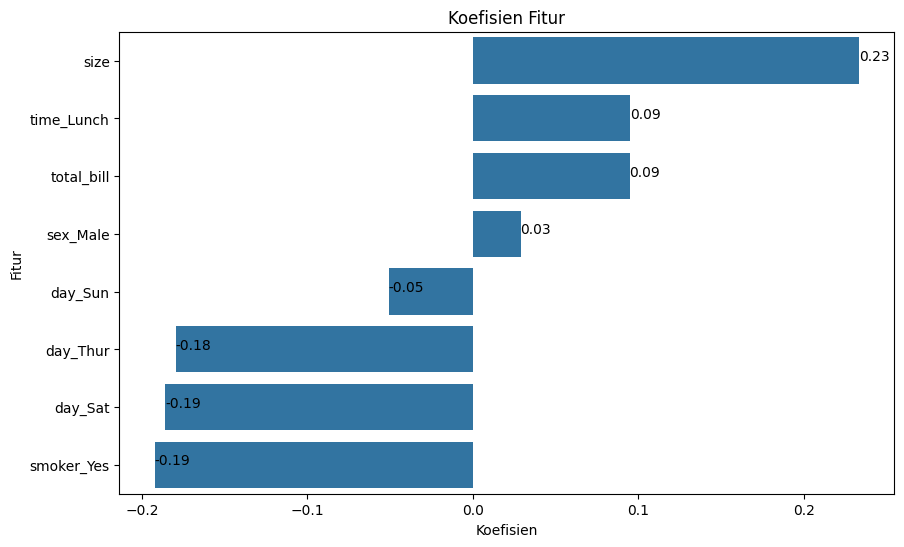

In [41]:
plt.figure(figsize=(10, 6))
sns.barplot(x=koef, y=koef.index)
plt.title('Koefisien Fitur')
for i in range(len(koef)):
    plt.text(koef[i], i, f'{koef[i]:.2f}', ha='left')
plt.xlabel('Koefisien')
plt.ylabel('Fitur')
plt.show()

Interpertasi Koef positif:
-  size (Jumlah Tamu) = +0.23: Ini adalah fitur yang memiliki pengaruh positif paling kuat. Artinya, setiap penambahan 1 orang tamu di meja, prediksi tip akan meningkat sebesar 0.23 (dalam satuan dolar), dengan asumsi variabel lain konstan. Logikanya masuk akal: semakin banyak orang yang makan, total tagihan dan porsi makanan biasanya makin besar, sehingga tip cenderung ikut naik.   
- time_Lunch = +0.09 & total_bill = +0.09: Keduanya memiliki pengaruh positif. Khusus untuk total_bill, semakin besar tagihan, tentu tip yang diberikan juga cenderung bertambah.
- sex_Male = +0.03: Pengaruhnya sangat kecil mendekati nol, yang mengindikasikan bahwa jenis kelamin pemberi tip hampir tidak memberikan perbedaan signifikan pada model regresi ini.

Interpertasi Koef Negatif:
- smoker_Yes = -0.19: Memiliki koefisien negatif yang cukup tinggi. Ini berarti, jika tamu tersebut adalah seorang perokok (smoker_Yes bernilai 1), model memprediksi tip yang diberikan akan lebih rendah sekitar 0.19 dibanding non-perokok (dengan asumsi variabel lain sama).
- day_Sat (-0.19) & day_Thur (-0.18): Dibandingkan hari pembanding (biasanya hari Minggu atau kategori acuan lain dalam one-hot encoding), hari Sabtu dan Kamis menunjukkan tren koefisien negatif terhadap besaran tip.
- day_Sun = -0.05: Berpengaruh sedikit negatif dibanding hari acuannya.

### Grafik Prediksi dengan Aktual

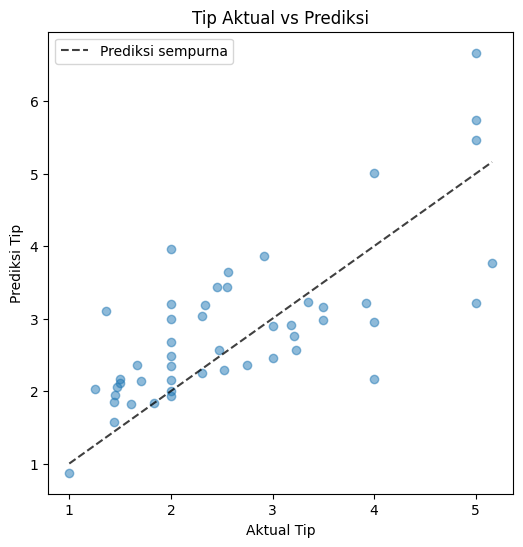

In [45]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)


lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'k--', alpha=0.75, label='Prediksi sempurna')
plt.xlabel('Aktual Tip')
plt.ylabel('Prediksi Tip')
plt.title('Tip Aktual vs Prediksi')
plt.legend()
plt.show()

Interpretasi:
- Titik mengelompok disekitar garis hitam, walaupun ada sebaran.
- Model menangkap tren umum dengan baik meski tidak sempurna pada kasus individual

## Kesimpulan dan Insight

- `total_bill` adalah prediktor terkuat** besar tip; faktor kategori kecil pengaruhnya.
- Persentase tip rata-rata stabil di ~16%, menegaskan pola "tip mengikuti tagihan".
- Model linear sederhana menjelaskan ~44% variasi tip (R²) dengan error <1 USD.



**Insight bisnis:**
  - untuk memprediksi pendapatan tip, cukup fokus pada nilai tagihan dan jumlah tamu; segmentasi berdasar hari/waktu memberi peningkatan kecil.